In [3]:
import scipy
import torch

n = 31000
p = 0.00203
k = 63

# comb
bi_coef = scipy.special.comb(31000,63)
probability = bi_coef * (p**k) * ((1-p)**(n-k))
print(probability)



0.05024468664277072


In [6]:
# table = [[39, 30961], [63, 30937]]
table = [[39, 63], [30961, 30937]]
stat, p_value = scipy.stats.fisher_exact(table, alternative='less')
print(stat,p_value)

0.6185677526719483 0.011094091841433758


In [3]:
import math
from scipy.stats import binom
import scipy.stats as stats
t = -2*math.log(binom.pmf(39,31000,102/62000)*binom.pmf(63,31000,102/62000)/(binom.pmf(39,31000,39/31000)*binom.pmf(63,31000,63/31000)))

p_value = stats.chi2.sf(t, df=1)
print(t, p_value)

5.709660479762185 0.016871802195942608


In [1]:
import numpy as np
Xs = np.array([0.0339, 0.0423, 0.213, 0.257, 0.273, 0.273, 0.450, 0.503, 0.503, 0.637, 0.805, 0.904, 0.904, 0.910, 0.910, 1.02, 1.11, 1.11, 1.41, 1.72, 2.03, 2.02, 2.02, 2.02])

Ys = np.array([-19.3, 30.4, 38.7, 5.52, -33.1, -77.3, 398.0, 406.0, 436.0, 320.0, 373.0, 93.9, 210.0, 423.0, 594.0, 829.0, 718.0, 561.0, 608.0, 1.04E3, 1.10E3, 840.0, 801.0, 519.0])

# barX barY
barX = np.average(Xs)
barY = np.average(Ys)
print(barX, barY)

# sX sY
# sX = np.std(Xs,)
# sY = np.std(Ys)
sX = np.sqrt(np.sum((Xs-barX)**2)/(23))
sY = np.sqrt(np.sum((Ys-barY)**2)/(23))
print(sX, sY)

# covariance
sXY = np.sum((Xs - barX) * (Ys - barY)) / 23
print(sXY)

# Beta1
r = sXY/(sX*sY)
beta1 = r * sY/sX
print(r, beta1)

# Beta0
beta0 = barY - beta1*barX
print(beta0)

0.9199250000000001 425.6175
0.6533948258734996 348.7336574977229
191.20706528260868
0.8391399162310663 447.87059914099837
13.610139085217043


13.665764009034303 84.42287983847875 0.9888323018726733


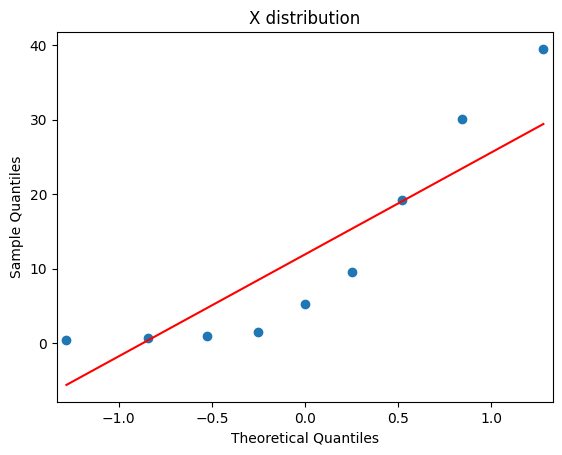

1.4995325773381896 0.0013370447605033594


: 

In [ ]:
Xs = np.array([ 0.387, 0.723, 1.00, 1.52, 5.20, 9.54, 19.2, 30.1, 39.5 ])
Ys = np.array([ 0.241, 0.615, 1.00, 1.88, 11.9, 29.5, 84.0, 165.0, 248 ])

barX = np.average(Xs)
barY = np.average(Ys)

sx = np.sqrt(np.sum((Xs - barX)**2) / 9)
sy = np.sqrt(np.sum((Ys - barY)**2) / 9)

cov = np.sum((Xs-np.average(Xs)) * (Ys-np.average(Ys))) / 9
r = cov / (sx*sy)
print(sx, sy, r)

import statsmodels.api as sm
import matplotlib.pyplot as plt
sm.qqplot(Xs, line='s')
plt.title("X distribution")
plt.show()

# ==========================================
# 2. 双对数变换 (Nonlinear Transformation)与拟合
# ==========================================
log_X = np.log(Xs)
log_Y = np.log(Ys)

log_X_with_constant = sm.add_constant(log_X)
log_model = sm.OLS(log_Y, log_X_with_constant).fit()

omega = log_model.params[1]
phi = log_model.params[0]
print(omega, phi)

In [4]:
import numpy as np
# 7. Model Selection and regularization
LogPlanetMass = np.array([-0.31471074,  1.01160091,  0.58778666,  0.46373402, -0.01005034,
         0.66577598, -1.30933332, -0.37106368, -0.40047757, -0.27443685,
         1.30833282, -0.46840491, -1.91054301,  0.16551444,  0.78845736,
        -2.43041846,  0.21511138,  2.29253476, -2.05330607, -0.43078292,
        -4.98204784, -0.48776035, -1.69298258, -0.08664781, -2.28278247,
         3.30431931, -3.27016912,  1.14644962, -3.10109279, -0.61248928])

LogPlanetRadius = np.array([ 0.32497786,  0.34712953,  0.14842001,  0.45742485,  0.1889661 ,
         0.06952606,  0.07696104,  0.3220835 ,  0.42918163, -0.05762911,
         0.40546511,  0.19227189, -0.16251893,  0.45107562,  0.3825376 ,
        -0.82098055,  0.10436002,  0.0295588 , -1.17921515,  0.55961579,
        -2.49253568,  0.11243543, -0.72037861,  0.36464311, -0.46203546,
         0.13976194, -2.70306266,  0.12221763, -2.41374014,  0.35627486])

LogPlanetOrbit = np.array([-2.63108916, -3.89026151, -3.13752628, -2.99633245, -3.12356565,
        -2.33924908, -2.8507665 , -3.04765735, -2.84043939, -3.19004544,
        -3.14655516, -3.13729584, -3.09887303, -3.09004295, -3.16296819,
        -2.3227878 , -3.77661837, -2.52572864, -4.13641734, -3.05018846,
        -2.40141145, -3.14795149, -0.40361682, -3.2148838 , -2.74575207,
        -3.70014265, -1.98923527, -3.35440922, -1.96897409, -2.99773428])

StarMetallicity = np.array([ 0.11 , -0.002, -0.4  ,  0.01 ,  0.15 ,  0.22 , -0.01 ,  0.02 ,
        -0.06 , -0.127,  0.   ,  0.12 ,  0.27 ,  0.09 , -0.077,  0.3  ,
         0.14 , -0.07 ,  0.19 , -0.02 ,  0.12 ,  0.251,  0.07 ,  0.16 ,
         0.19 ,  0.052, -0.32 ,  0.258,  0.02 , -0.17 ])

LogStarMass = np.array([ 0.27002714,  0.19144646, -0.16369609,  0.44468582,  0.19227189,
         0.01291623,  0.0861777 ,  0.1380213 ,  0.49469624, -0.43850496,
         0.54232429,  0.02469261,  0.07325046,  0.42133846,  0.2592826 ,
        -0.09431068, -0.24846136, -0.12783337, -0.07364654,  0.26159474,
         0.07603469, -0.07796154,  0.09440068,  0.07510747,  0.17395331,
         0.28893129, -0.21940057,  0.02566775, -0.09211529,  0.16551444])

LogStarAge = np.array([ 1.58103844,  1.06471074,  2.39789527,  0.72754861,  0.55675456,
         1.91692261,  1.64865863,  1.38629436,  0.77472717,  1.36097655,
         0.        ,  1.80828877,  1.7837273 ,  0.64185389,  0.69813472,
         2.39789527, -0.35667494,  1.79175947,  1.90210753,  1.39624469,
         1.84054963,  2.19722458,  1.89761986,  1.84054963,  0.74193734,
         0.55961579,  1.79175947,  0.91629073,  2.17475172,  1.36097655])

N = 30

X = np.column_stack((
  np.ones(N),
  LogPlanetRadius,
  LogPlanetOrbit,
  StarMetallicity,
  LogStarMass,
  LogStarAge
))

y = LogPlanetMass
hatbeta = np.linalg.inv(X.T @ X) @ X.T @ y
print(hatbeta)

# First, estimate the standard deviation of the noise.
sigmaHat = np.sqrt( np.sum( np.square(LogPlanetMass - X.dot(hatbeta) )) / ( N - X.shape[1] ) )
# Now estimate the (matrix part of the) covariance matrix for beta 
import numpy.linalg
betaCov = numpy.linalg.inv(X.T.dot(X))
# Use the formula for the t-test statistic for each variable
tVals = hatbeta/(sigmaHat * np.sqrt(np.diagonal(betaCov)))
# Calculate the 2-sided p-values.
import scipy.stats
pvals = scipy.stats.t.sf(np.abs(tVals), N-X.shape[1])*2

print(pvals)

[ 0.15379303  1.40214538 -0.14099818 -1.59951364 -0.95610919 -0.46176234]
[9.12757006e-01 5.43077387e-05 6.98598654e-01 2.13109749e-01
 4.00456619e-01 2.25952781e-01]
